In [1]:
# ============================================================
# Project 4: UK Labour Market Post-Pandemic
# Analyst: Adebowale Adebare
# Data Source: ONS Labour Market Statistics A01 (September 2026)
# Date: September 2026
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load ONS A01 Sheet 1
df_raw = pd.read_excel(
    r"C:\Portfolio\Project4_Labour_Market\data\a01sep2026.xls",
    sheet_name='1',
    header=None,
    engine='xlrd'
)

# Select and rename relevant columns
df_labour = df_raw.iloc[9:, [0, 3, 4, 16, 8]].copy()
df_labour.columns = ['Period', 'Employment_Level',
                     'Unemployment_Level', 'Employment_Rate',
                     'Unemployment_Rate']

# Round numbers cleanly
df_labour['Employment_Level'] = df_labour['Employment_Level'].astype(float).round(0)
df_labour['Unemployment_Level'] = df_labour['Unemployment_Level'].astype(float).round(0)
df_labour['Employment_Rate'] = df_labour['Employment_Rate'].astype(float).round(1)
df_labour['Unemployment_Rate'] = df_labour['Unemployment_Rate'].astype(float).round(1)

# Remove nulls and filter to 2000 onwards
df_labour = df_labour.dropna(subset=['Period'])
df_labour = df_labour[df_labour['Period'].astype(str).str.contains(
    '200|201|202', regex=True
)]

# Remove rows with null rates
df_valid = df_labour.dropna(subset=['Employment_Rate', 'Unemployment_Rate'])

# Filter to quarterly periods only for clean charts
df_quarterly = df_valid[df_valid['Period'].astype(str).str.contains(
    'Jan-Mar|Apr-Jun|Jul-Sep|Oct-Dec', regex=True
)].copy()

print(f"Total rows: {df_valid.shape[0]}")
print(f"Quarterly rows: {df_quarterly.shape[0]}")
df_quarterly.head()

Total rows: 319
Quarterly rows: 106


,Period,Employment_Level,Unemployment_Level,Employment_Rate,Unemployment_Rate
357,Jan-Mar 2000,27361931.0,1682476.0,72.3,5.8
360,Apr-Jun 2000,27468086.0,1598836.0,72.5,5.5
363,Jul-Sep 2000,27555105.0,1547854.0,72.6,5.3
366,Oct-Dec 2000,27548559.0,1519515.0,72.5,5.2
369,Jan-Mar 2001,27623323.0,1481307.0,72.6,5.1


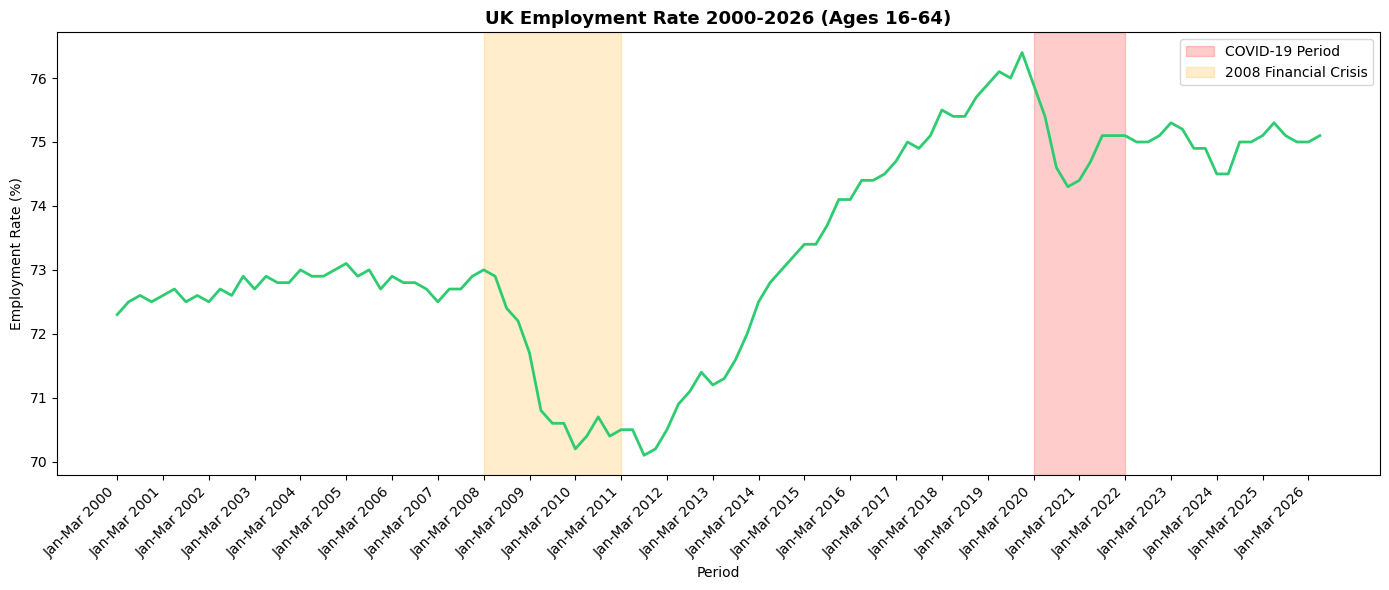

In [3]:
# Q1: UK Employment Rate Trend 2000-2026
plt.figure(figsize=(14, 6))
plt.plot(range(len(df_quarterly)),
         df_quarterly['Employment_Rate'],
         color='#2ecc71', linewidth=2)

plt.axvspan(80, 88, alpha=0.2, color='red', label='COVID-19 Period')
plt.axvspan(32, 44, alpha=0.2, color='orange', label='2008 Financial Crisis')

plt.title('UK Employment Rate 2000-2026 (Ages 16-64)',
          fontsize=13, fontweight='bold')
plt.ylabel('Employment Rate (%)')
plt.xlabel('Period')
plt.xticks(range(0, len(df_quarterly), 4),
           df_quarterly['Period'].iloc[::4],
           rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Portfolio\Project4_Labour_Market\chart1_employment_rate.png", dpi=150)
plt.show()

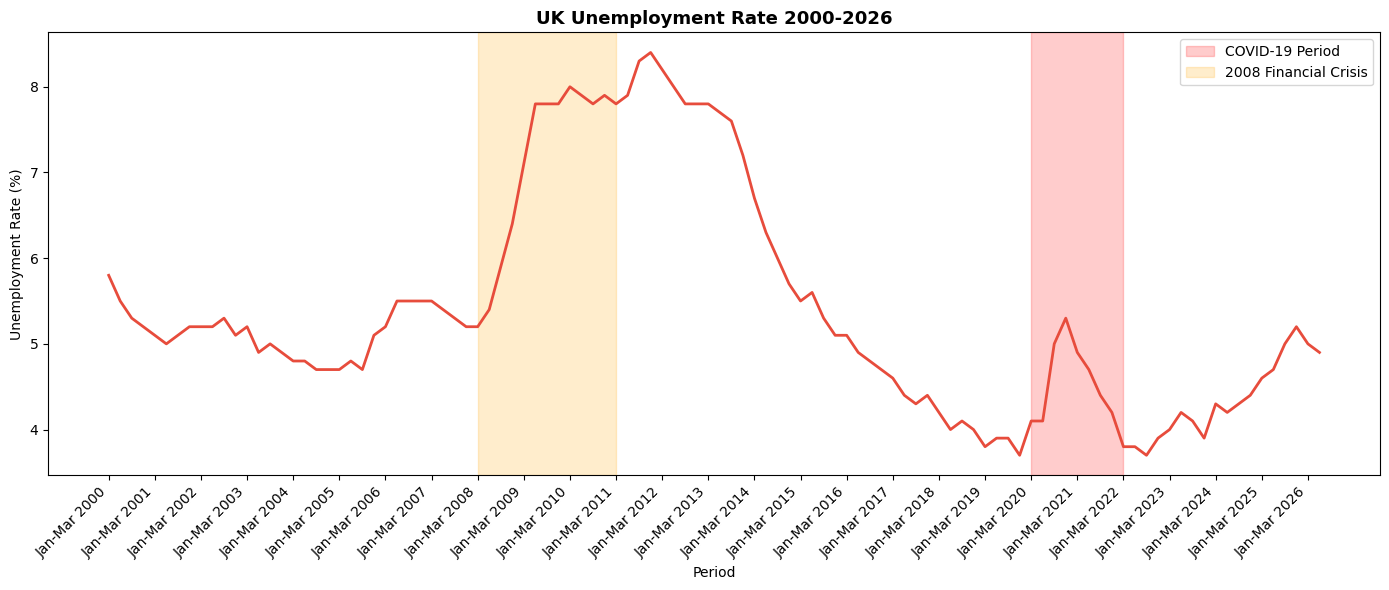

In [4]:
# Q2: UK Unemployment Rate Trend 2000-2026
plt.figure(figsize=(14, 6))
plt.plot(range(len(df_quarterly)),
         df_quarterly['Unemployment_Rate'],
         color='#e74c3c', linewidth=2)

plt.axvspan(80, 88, alpha=0.2, color='red', label='COVID-19 Period')
plt.axvspan(32, 44, alpha=0.2, color='orange', label='2008 Financial Crisis')

plt.title('UK Unemployment Rate 2000-2026',
          fontsize=13, fontweight='bold')
plt.ylabel('Unemployment Rate (%)')
plt.xlabel('Period')
plt.xticks(range(0, len(df_quarterly), 4),
           df_quarterly['Period'].iloc[::4],
           rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Portfolio\Project4_Labour_Market\chart2_unemployment_rate.png", dpi=150)
plt.show()

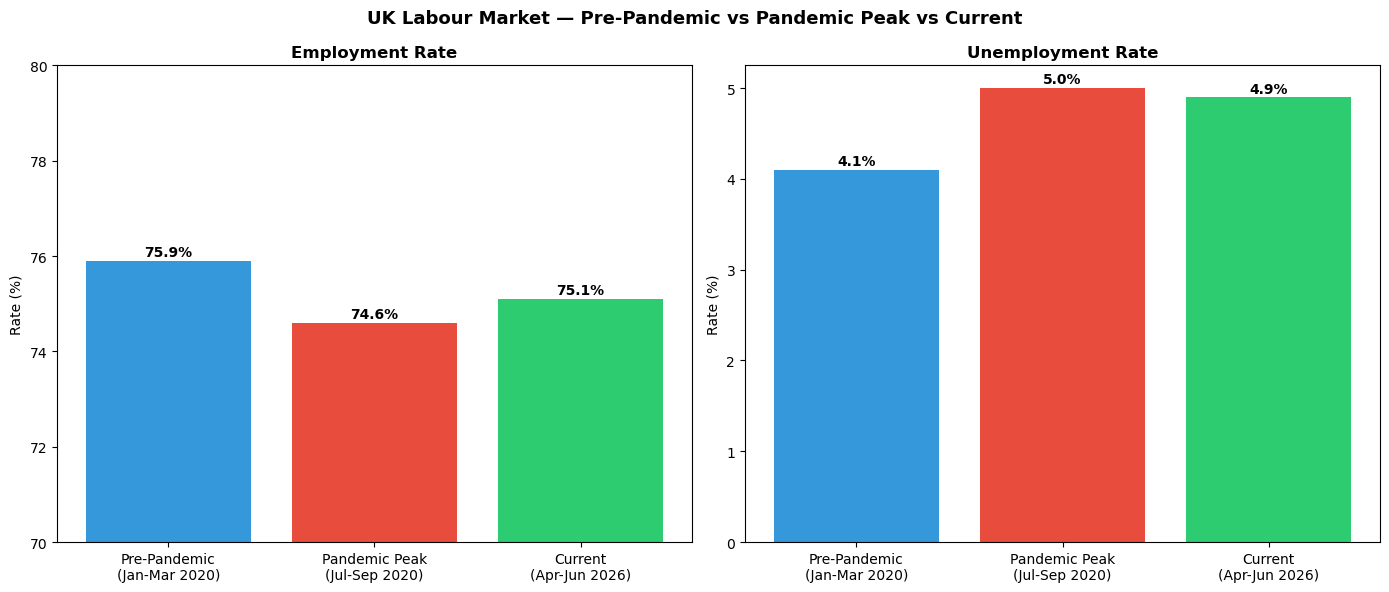

Pre-Pandemic Employment Rate: 75.9%
Pandemic Peak Employment Rate: 74.6%
Current Employment Rate: 75.1%

Pre-Pandemic Unemployment Rate: 4.1%
Pandemic Peak Unemployment Rate: 5.0%
Current Unemployment Rate: 4.9%


In [5]:
# Q3: Pre-Pandemic vs Pandemic Peak vs Current
pre_pandemic = df_quarterly[df_quarterly['Period'] == 'Jan-Mar 2020']
pandemic_peak = df_quarterly[df_quarterly['Period'] == 'Jul-Sep 2020']
current = df_quarterly.iloc[-1]

periods = ['Pre-Pandemic\n(Jan-Mar 2020)',
           'Pandemic Peak\n(Jul-Sep 2020)',
           f'Current\n({df_quarterly["Period"].iloc[-1]})']

employment_rates = [
    float(pre_pandemic['Employment_Rate'].values[0]),
    float(pandemic_peak['Employment_Rate'].values[0]),
    float(current['Employment_Rate'])
]

unemployment_rates = [
    float(pre_pandemic['Unemployment_Rate'].values[0]),
    float(pandemic_peak['Unemployment_Rate'].values[0]),
    float(current['Unemployment_Rate'])
]

colors = ['#3498db', '#e74c3c', '#2ecc71']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

bars1 = ax1.bar(periods, employment_rates, color=colors)
for bar, val in zip(bars1, employment_rates):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val}%', ha='center', fontweight='bold')
ax1.set_title('Employment Rate', fontsize=12, fontweight='bold')
ax1.set_ylabel('Rate (%)')
ax1.set_ylim(70, 80)

bars2 = ax2.bar(periods, unemployment_rates, color=colors)
for bar, val in zip(bars2, unemployment_rates):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{val}%', ha='center', fontweight='bold')
ax2.set_title('Unemployment Rate', fontsize=12, fontweight='bold')
ax2.set_ylabel('Rate (%)')

plt.suptitle('UK Labour Market — Pre-Pandemic vs Pandemic Peak vs Current',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Portfolio\Project4_Labour_Market\chart3_comparison.png", dpi=150)
plt.show()

print(f"Pre-Pandemic Employment Rate: {employment_rates[0]}%")
print(f"Pandemic Peak Employment Rate: {employment_rates[1]}%")
print(f"Current Employment Rate: {employment_rates[2]}%")
print(f"\nPre-Pandemic Unemployment Rate: {unemployment_rates[0]}%")
print(f"Pandemic Peak Unemployment Rate: {unemployment_rates[1]}%")
print(f"Current Unemployment Rate: {unemployment_rates[2]}%")

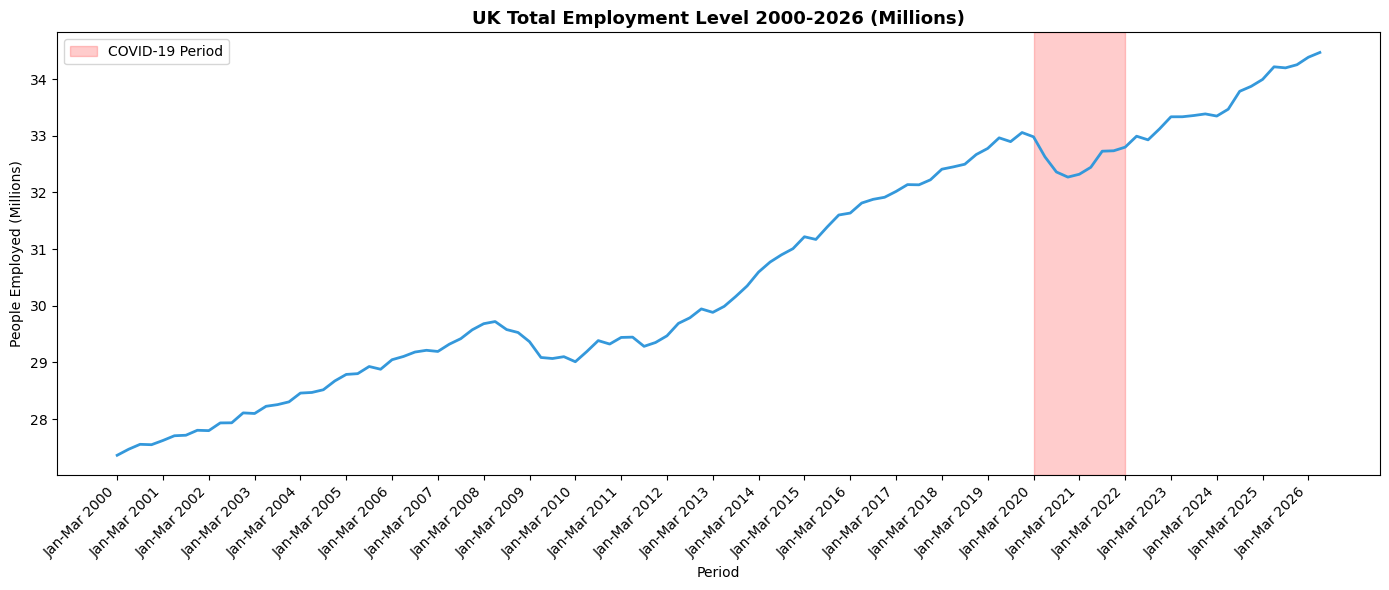

In [6]:
# Q4: UK Total Employment Level 2000-2026
plt.figure(figsize=(14, 6))
plt.plot(range(len(df_quarterly)),
         df_quarterly['Employment_Level'] / 1000000,
         color='#3498db', linewidth=2)

plt.axvspan(80, 88, alpha=0.2, color='red', label='COVID-19 Period')

plt.title('UK Total Employment Level 2000-2026 (Millions)',
          fontsize=13, fontweight='bold')
plt.ylabel('People Employed (Millions)')
plt.xlabel('Period')
plt.xticks(range(0, len(df_quarterly), 4),
           df_quarterly['Period'].iloc[::4],
           rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Portfolio\Project4_Labour_Market\chart4_employment_level.png", dpi=150)
plt.show()

In [7]:
# Convert Period to date and export for Tableau
def period_to_date(period):
    try:
        first_month = period.split('-')[0]
        year = period.split(' ')[-1]
        return pd.to_datetime(f"01 {first_month} {year}", format='%d %b %Y')
    except:
        return None

df_quarterly['Date'] = df_quarterly['Period'].apply(period_to_date)

df_quarterly.to_csv(
    r"C:\Portfolio\Project4_Labour_Market\data\labour_market_clean.csv",
    index=False
)
print(f"Exported {df_quarterly.shape[0]} rows successfully!")
df_quarterly[['Period', 'Date']].head()

Exported 106 rows successfully!


,Period,Date
357,Jan-Mar 2000,2000-01-01
360,Apr-Jun 2000,2000-04-01
363,Jul-Sep 2000,2000-07-01
366,Oct-Dec 2000,2000-10-01
369,Jan-Mar 2001,2001-01-01


In [8]:
# Check if Date column exists and has values
print(df_quarterly.columns.tolist())
print(df_quarterly[['Period', 'Date']].head(10))
print(f"\nNull dates: {df_quarterly['Date'].isna().sum()}")

['Period', 'Employment_Level', 'Unemployment_Level', 'Employment_Rate', 'Unemployment_Rate', 'Date']
           Period       Date
357  Jan-Mar 2000 2000-01-01
360  Apr-Jun 2000 2000-04-01
363  Jul-Sep 2000 2000-07-01
366  Oct-Dec 2000 2000-10-01
369  Jan-Mar 2001 2001-01-01
372  Apr-Jun 2001 2001-04-01
375  Jul-Sep 2001 2001-07-01
378  Oct-Dec 2001 2001-10-01
381  Jan-Mar 2002 2002-01-01
384  Apr-Jun 2002 2002-04-01

Null dates: 0
